# 09. 한 장의 사진에서 거리감 추정: Depth Estimation

**실습 목표**  
단일 RGB 이미지로부터 상대적 깊이 지도를 생성하고 시각화한다.

**주요 Hugging Face 모델**  
`Intel/dpt-hybrid-midas`

> 이 노트북은 **파인튜닝 없이 사전학습 모델을 추론에 활용**하는 실습이다.  
> RTX 4060 8GB 환경을 고려했으며, CUDA가 없으면 CPU로 자동 전환하도록 구성하였다.

In [2]:
# uv add transformers accelerate pillow requests matplotlib

In [3]:
import torch
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
DEVICE = 0 if torch.cuda.is_available() else -1
TORCH_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", TORCH_DEVICE)

PyTorch: 2.14.0+cu126
CUDA available: True
device: cuda


In [4]:
from PIL import Image
import requests
from io import BytesIO

def load_image(url):
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    return Image.open(BytesIO(r.content)).convert("RGB")

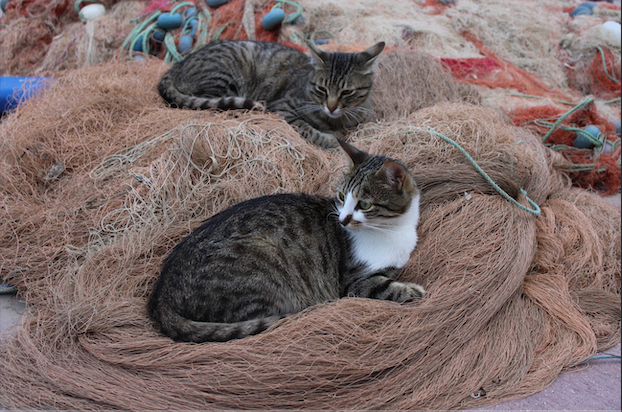

In [5]:
image = load_image("https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/cats.png")
display(image)

In [6]:
from transformers import pipeline
depth_estimator = pipeline(
    "depth-estimation",
    model="Intel/dpt-hybrid-midas",
    device=DEVICE
)
pred = depth_estimator(image)
pred.keys()

config.json:   0%|          | 0.00/9.88k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  490MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/414 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  490MB            

model.safetensors: downloading bytes:           |  0.00B            

preprocessor_config.json:   0%|          | 0.00/382 [00:00<?, ?B/s]

dict_keys(['predicted_depth', 'depth'])

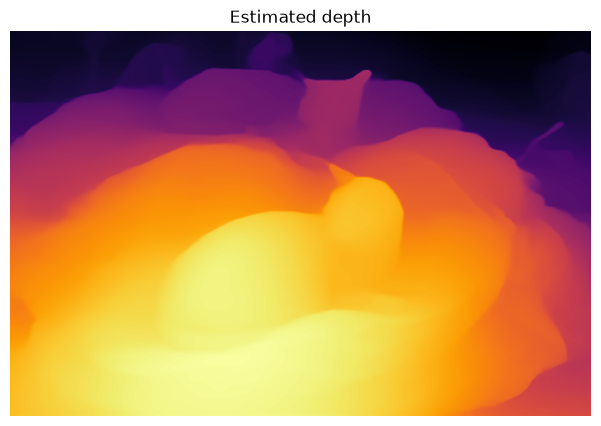

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.imshow(pred["depth"], cmap="inferno")
plt.axis("off")
plt.title("Estimated depth")
plt.show()